In [1]:
# CELL 1: SETUP & IMPORTS
import os
import time
import json
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Buat folder untuk menyimpan semua hasil agar tidak berantakan
SAVE_DIR = "results_exp0"
os.makedirs(SAVE_DIR, exist_ok=True)

# Cek ketersediaan GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")
if torch.cuda.is_available():
    print(f"Nama GPU: {torch.cuda.get_device_name(0)}")

Menggunakan device: cuda
Nama GPU: NVIDIA GeForce RTX 5070


In [2]:
# CELL 2: FOCAL LOSS
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [2]:
# CELL 3: DATASET & STRATIFIED K-FOLD (UPDATED LOCAL PATHS)
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import StratifiedKFold

# 1. Kunci Lokasi Data Lokal
data_dir = r"C:\Users\asfan\Data\ham10000\full"
csv_path = r"C:\Users\asfan\Data\ham10000\HAM10000_metadata.csv"

# 2. Baca Metadata dan Petakan Kelas
df = pd.read_csv(csv_path)
class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
class_to_idx = {c: i for i, c in enumerate(class_names)}

# Mapping kelas teks ('dx') menjadi indeks angka
df['label'] = df['dx'].map(class_to_idx)

# Membangun full path untuk setiap gambar secara otomatis
# Asumsi format gambar adalah .jpg dan nama file sama dengan image_id
df['image_path'] = df.apply(lambda row: os.path.join(data_dir, row['dx'], f"{row['image_id']}.jpg"), axis=1)

# Verifikasi path (Cek apakah gambar pertama benar-benar ada)
print(f"Total data: {len(df)}")
print(f"Contoh path gambar: {df.iloc[0]['image_path']}")
if not os.path.exists(df.iloc[0]['image_path']):
    print("WARNING: Path gambar tidak ditemukan! Pastikan ekstensi .jpg atau nama folder sesuai.")

# 3. Class Dataset Kustom
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label']
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# 4. Augmentasi Data
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 5. Persiapan Stratified 5-Fold
X = df['image_path'].values
y = df['label'].values
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Dataset dan Stratified K-Fold siap!")

Total data: 10015
Contoh path gambar: C:\Users\asfan\Data\ham10000\full\bkl\ISIC_0027419.jpg
Dataset dan Stratified K-Fold siap!


In [4]:
import torch
import torch.nn as nn
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

# =========================================================
# CELL 4: MODEL ARCHITECTURE (Baseline ConvNeXt Tanpa Attention)
# =========================================================

class ConvNeXt_Baseline(nn.Module):
    def __init__(self, num_classes=7):
        super(ConvNeXt_Baseline, self).__init__()
        # Load pre-trained ConvNeXt-Tiny
        convnext = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        
        # Ekstrak feature extractor
        self.features = convnext.features
        
        # TIDAK ADA ATTENTION BLOCK DI SINI
        
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        
        # Classifier (Flatten diletakkan sebelum LayerNorm)
        self.classifier = nn.Sequential(
            nn.Flatten(1),                     # Ubah dari (Batch, 768, 1, 1) menjadi (Batch, 768)
            nn.LayerNorm(768, eps=1e-6),       # LayerNorm menerima bentuk yang benar
            nn.Linear(768, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        # x = self.se_block(x)  <-- DIHAPUS
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

# Test inisialisasi model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_test = ConvNeXt_Baseline().to(device)
print(f"Total parameter Baseline: {sum(p.numel() for p in model_test.parameters())}")

Total parameter Baseline: 27825511


In [7]:
# CELL 5: TRAINING ENGINE WITH METRIC TRACKING
def train_model(fold, model, train_loader, val_loader, criterion, optimizer, num_epochs=50):
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    start_time = time.time()
    torch.cuda.reset_peak_memory_stats()
    
    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
            total += labels.size(0)
            
        epoch_train_loss = running_loss / total
        epoch_train_acc = correct.double() / total
        
        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels.data)
                val_total += labels.size(0)
                
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct.double() / val_total
        
        # Simpan metrik
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc.item())
        history['val_acc'].append(epoch_val_acc.item())
        
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
        
        # Simpan model terbaik (.pth)
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            model_save_path = os.path.join(SAVE_DIR, f"exp0_fold{fold}_best_model.pth")
            torch.save(model.state_dict(), model_save_path)
            
    # Kalkulasi performa hardware
    end_time = time.time()
    training_time = end_time - start_time
    max_memory = torch.cuda.max_memory_allocated() / (1024 ** 2) # Dalam MB
    
    # Simpan history ke JSON
    with open(os.path.join(SAVE_DIR, f"exp0_fold{fold}_history.json"), 'w') as f:
        json.dump(history, f)
        
    return history, training_time, max_memory

In [8]:
# CELL 6: EVALUATION & REPORTING
def evaluate_and_plot(fold, model, val_loader, history, training_time, max_memory, class_names):
    # Load model terbaik
    model.load_state_dict(torch.load(os.path.join(SAVE_DIR, f"exp0_fold{fold}_best_model.pth")))
    model.eval()
    
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # 1. Classification Report & Metrics
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(SAVE_DIR, f"exp0_fold{fold}_classification_report.csv"))
    
    # Simpan resource metrik
    resource_log = {
        'training_time_seconds': training_time,
        'max_gpu_memory_mb': max_memory,
        'overall_accuracy': accuracy_score(all_labels, all_preds)
    }
    with open(os.path.join(SAVE_DIR, f"exp0_fold{fold}_resources.json"), 'w') as f:
        json.dump(resource_log, f)
        
    # 2. Plot Loss & Accuracy Curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_title(f'Loss Curve - Fold {fold}')
    ax1.legend()
    
    ax2.plot(history['train_acc'], label='Train Acc')
    ax2.plot(history['val_acc'], label='Val Acc')
    ax2.set_title(f'Accuracy Curve - Fold {fold}')
    ax2.legend()
    plt.savefig(os.path.join(SAVE_DIR, f"exp0_fold{fold}_learning_curves.png"))
    plt.show()
    
    # 3. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(os.path.join(SAVE_DIR, f"exp0_fold{fold}_confusion_matrix.png"))
    plt.show()
    
    print(f"Semua log dan grafik untuk Fold {fold} berhasil disimpan di folder: {SAVE_DIR}")

# CONTOH EKSEKUSI (Bisa diletakkan di dalam loop Stratified K-Fold)
# class_names = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
# criterion = FocalLoss(gamma=2)
# optimizer = optim.Adam(model.parameters(), lr=1e-4)
# history, t_time, max_mem = train_model(fold=1, model=model, train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer)
# evaluate_and_plot(fold=1, model=model, val_loader=val_loader, history=history, training_time=t_time, max_memory=max_mem, class_names=class_names)

Mulai Eksperimen 0: ConvNeXt Baseline + Focal Loss
Menyimpan di folder: results_exp0

---> Memulai Fold 1 <---
Epoch 1/50 - Train Loss: 0.4094 Acc: 0.7431 | Val Loss: 0.2413 Acc: 0.8023
Epoch 2/50 - Train Loss: 0.2119 Acc: 0.8341 | Val Loss: 0.1763 Acc: 0.8572
Epoch 3/50 - Train Loss: 0.1510 Acc: 0.8743 | Val Loss: 0.1652 Acc: 0.8762
Epoch 4/50 - Train Loss: 0.1047 Acc: 0.9055 | Val Loss: 0.1417 Acc: 0.8827
Epoch 5/50 - Train Loss: 0.0734 Acc: 0.9310 | Val Loss: 0.1290 Acc: 0.8942
Epoch 6/50 - Train Loss: 0.0560 Acc: 0.9415 | Val Loss: 0.1277 Acc: 0.9041
Epoch 7/50 - Train Loss: 0.0453 Acc: 0.9538 | Val Loss: 0.1421 Acc: 0.8902
Epoch 8/50 - Train Loss: 0.0383 Acc: 0.9619 | Val Loss: 0.1432 Acc: 0.8997
Epoch 9/50 - Train Loss: 0.0281 Acc: 0.9703 | Val Loss: 0.1290 Acc: 0.9061
Epoch 10/50 - Train Loss: 0.0260 Acc: 0.9722 | Val Loss: 0.1501 Acc: 0.8977
Epoch 11/50 - Train Loss: 0.0214 Acc: 0.9763 | Val Loss: 0.1547 Acc: 0.9081
Epoch 12/50 - Train Loss: 0.0209 Acc: 0.9772 | Val Loss: 0.157

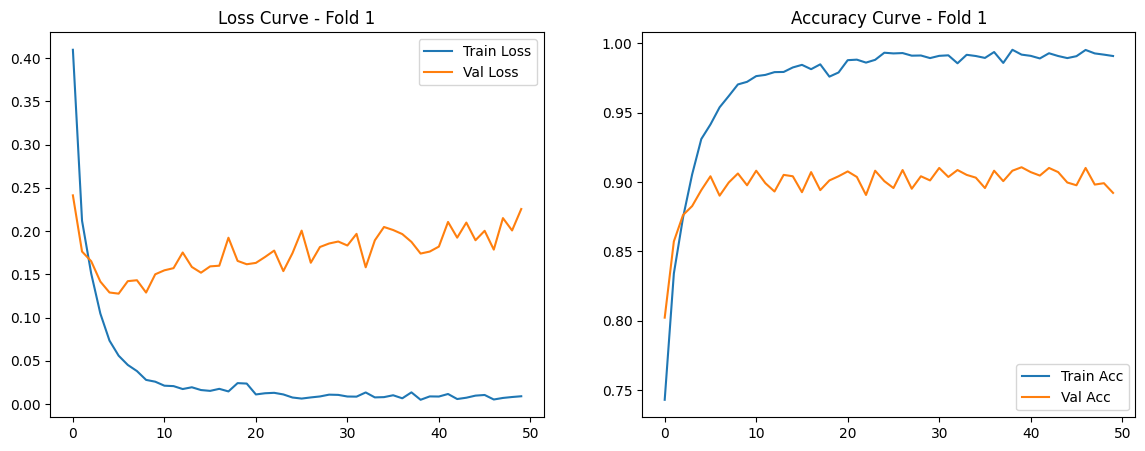

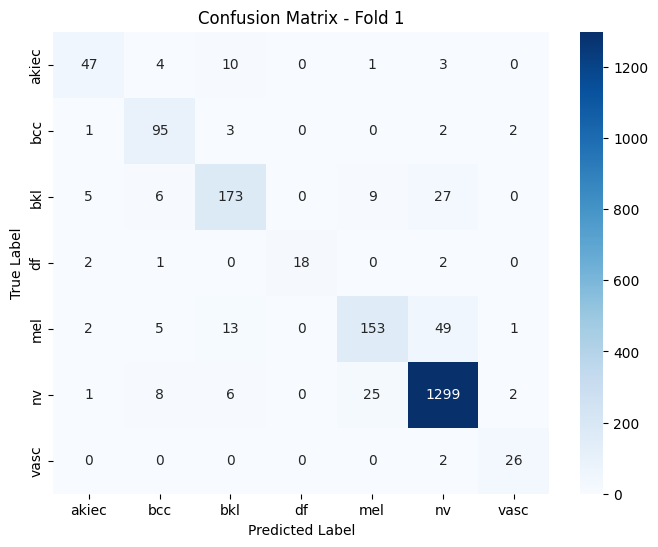

Semua log dan grafik untuk Fold 1 berhasil disimpan di folder: results_exp0

---> Memulai Fold 2 <---
Epoch 1/50 - Train Loss: 0.4037 Acc: 0.7449 | Val Loss: 0.2575 Acc: 0.8228
Epoch 2/50 - Train Loss: 0.2099 Acc: 0.8385 | Val Loss: 0.1821 Acc: 0.8542
Epoch 3/50 - Train Loss: 0.1428 Acc: 0.8747 | Val Loss: 0.1679 Acc: 0.8692
Epoch 4/50 - Train Loss: 0.1095 Acc: 0.8984 | Val Loss: 0.1792 Acc: 0.8507
Epoch 5/50 - Train Loss: 0.0774 Acc: 0.9262 | Val Loss: 0.1507 Acc: 0.8867
Epoch 6/50 - Train Loss: 0.0589 Acc: 0.9385 | Val Loss: 0.1550 Acc: 0.8897
Epoch 7/50 - Train Loss: 0.0541 Acc: 0.9455 | Val Loss: 0.1533 Acc: 0.8922
Epoch 8/50 - Train Loss: 0.0326 Acc: 0.9649 | Val Loss: 0.1431 Acc: 0.9061
Epoch 9/50 - Train Loss: 0.0276 Acc: 0.9695 | Val Loss: 0.1362 Acc: 0.9066
Epoch 10/50 - Train Loss: 0.0278 Acc: 0.9704 | Val Loss: 0.1630 Acc: 0.8862
Epoch 11/50 - Train Loss: 0.0174 Acc: 0.9829 | Val Loss: 0.1454 Acc: 0.9086
Epoch 12/50 - Train Loss: 0.0221 Acc: 0.9750 | Val Loss: 0.1432 Acc: 0.

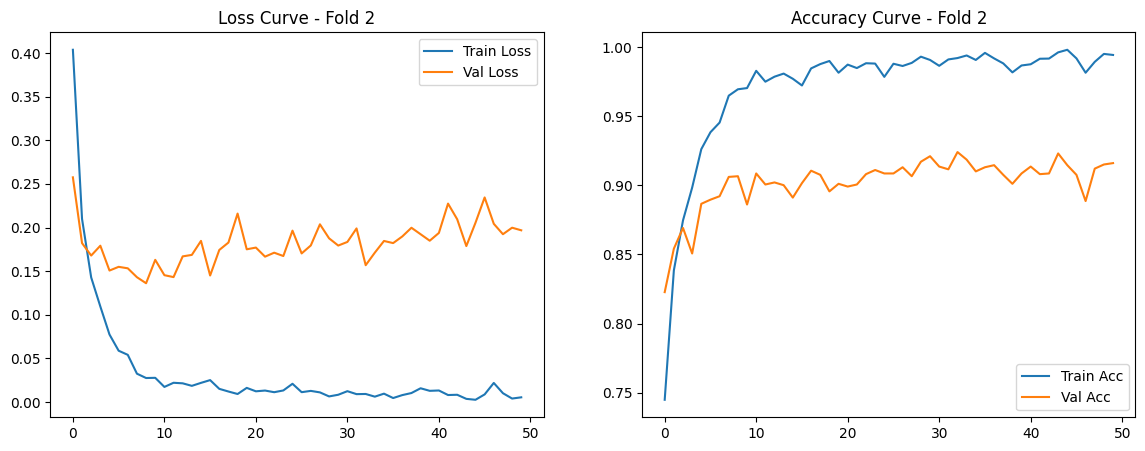

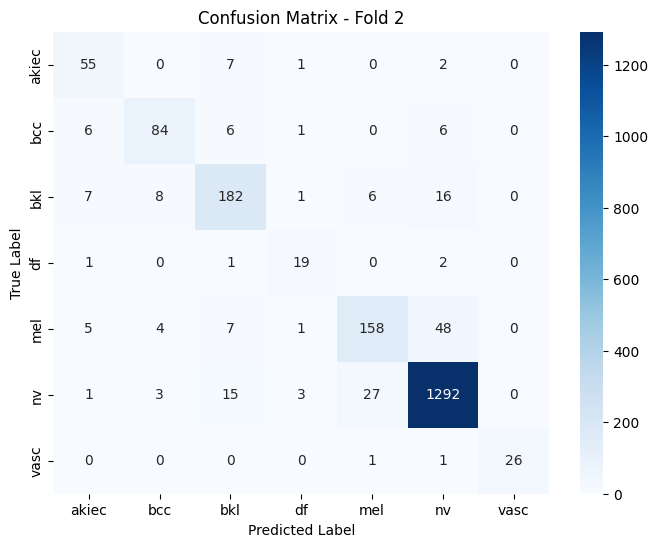

Semua log dan grafik untuk Fold 2 berhasil disimpan di folder: results_exp0

---> Memulai Fold 3 <---
Epoch 1/50 - Train Loss: 0.3911 Acc: 0.7530 | Val Loss: 0.2578 Acc: 0.8243
Epoch 2/50 - Train Loss: 0.2024 Acc: 0.8435 | Val Loss: 0.2134 Acc: 0.8407
Epoch 3/50 - Train Loss: 0.1402 Acc: 0.8793 | Val Loss: 0.1784 Acc: 0.8587
Epoch 4/50 - Train Loss: 0.1028 Acc: 0.9079 | Val Loss: 0.1763 Acc: 0.8647
Epoch 5/50 - Train Loss: 0.0742 Acc: 0.9291 | Val Loss: 0.1791 Acc: 0.8597
Epoch 6/50 - Train Loss: 0.0607 Acc: 0.9380 | Val Loss: 0.1827 Acc: 0.8537
Epoch 7/50 - Train Loss: 0.0421 Acc: 0.9571 | Val Loss: 0.1438 Acc: 0.8877
Epoch 8/50 - Train Loss: 0.0288 Acc: 0.9677 | Val Loss: 0.1659 Acc: 0.8912
Epoch 9/50 - Train Loss: 0.0326 Acc: 0.9646 | Val Loss: 0.1774 Acc: 0.8912
Epoch 10/50 - Train Loss: 0.0302 Acc: 0.9692 | Val Loss: 0.1741 Acc: 0.8947
Epoch 11/50 - Train Loss: 0.0239 Acc: 0.9748 | Val Loss: 0.1828 Acc: 0.8847
Epoch 12/50 - Train Loss: 0.0209 Acc: 0.9762 | Val Loss: 0.1897 Acc: 0.

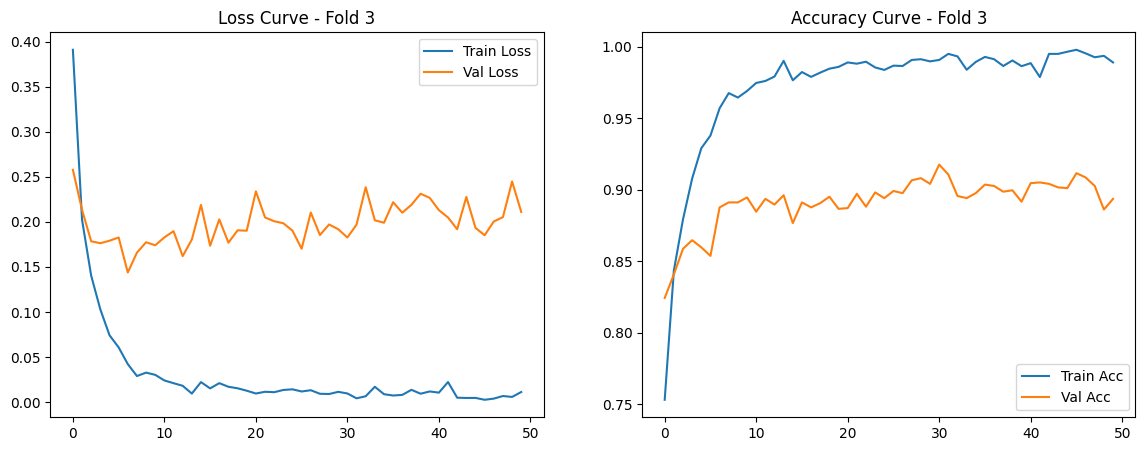

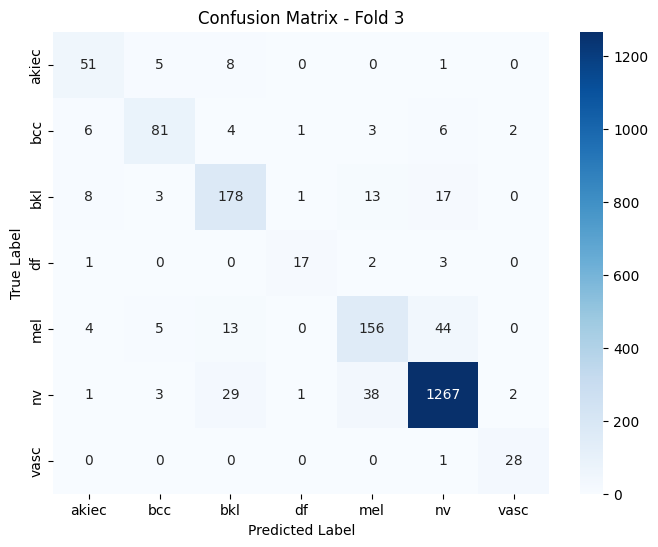

Semua log dan grafik untuk Fold 3 berhasil disimpan di folder: results_exp0

---> Memulai Fold 4 <---
Epoch 1/50 - Train Loss: 0.3972 Acc: 0.7499 | Val Loss: 0.2693 Acc: 0.7564
Epoch 2/50 - Train Loss: 0.2075 Acc: 0.8355 | Val Loss: 0.2065 Acc: 0.8412
Epoch 3/50 - Train Loss: 0.1473 Acc: 0.8774 | Val Loss: 0.1654 Acc: 0.8662
Epoch 4/50 - Train Loss: 0.1091 Acc: 0.9025 | Val Loss: 0.1689 Acc: 0.8657
Epoch 5/50 - Train Loss: 0.0752 Acc: 0.9262 | Val Loss: 0.1513 Acc: 0.8897
Epoch 6/50 - Train Loss: 0.0609 Acc: 0.9406 | Val Loss: 0.1867 Acc: 0.8657
Epoch 7/50 - Train Loss: 0.0494 Acc: 0.9517 | Val Loss: 0.1557 Acc: 0.8857
Epoch 8/50 - Train Loss: 0.0359 Acc: 0.9623 | Val Loss: 0.1567 Acc: 0.8992
Epoch 9/50 - Train Loss: 0.0273 Acc: 0.9720 | Val Loss: 0.1358 Acc: 0.9041
Epoch 10/50 - Train Loss: 0.0253 Acc: 0.9720 | Val Loss: 0.1658 Acc: 0.8947
Epoch 11/50 - Train Loss: 0.0210 Acc: 0.9773 | Val Loss: 0.1418 Acc: 0.9111
Epoch 12/50 - Train Loss: 0.0236 Acc: 0.9762 | Val Loss: 0.1798 Acc: 0.

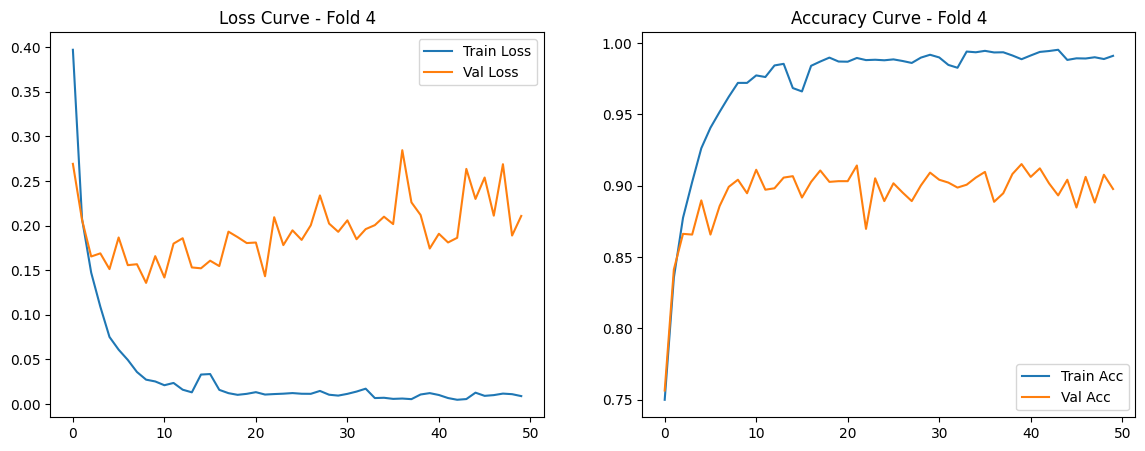

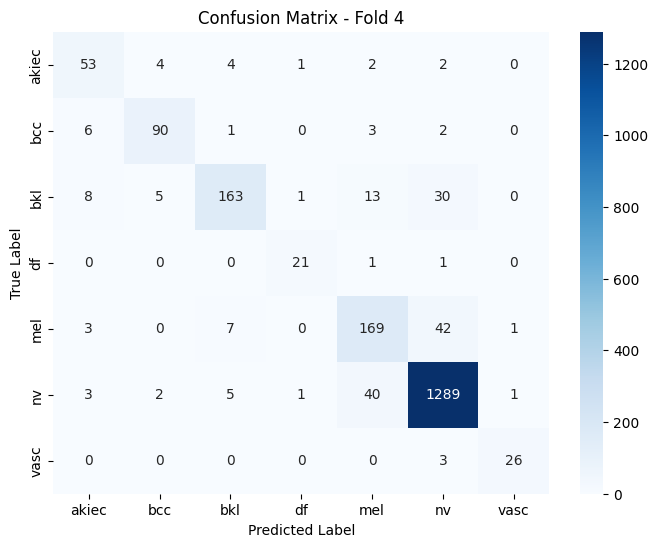

Semua log dan grafik untuk Fold 4 berhasil disimpan di folder: results_exp0

---> Memulai Fold 5 <---
Epoch 1/50 - Train Loss: 0.4063 Acc: 0.7476 | Val Loss: 0.2361 Acc: 0.8213
Epoch 2/50 - Train Loss: 0.2063 Acc: 0.8390 | Val Loss: 0.2113 Acc: 0.8377
Epoch 3/50 - Train Loss: 0.1472 Acc: 0.8782 | Val Loss: 0.1513 Acc: 0.8747
Epoch 4/50 - Train Loss: 0.0991 Acc: 0.9074 | Val Loss: 0.1400 Acc: 0.8822
Epoch 5/50 - Train Loss: 0.0676 Acc: 0.9356 | Val Loss: 0.1403 Acc: 0.8872
Epoch 6/50 - Train Loss: 0.0586 Acc: 0.9410 | Val Loss: 0.1633 Acc: 0.8792
Epoch 7/50 - Train Loss: 0.0467 Acc: 0.9483 | Val Loss: 0.1648 Acc: 0.8847
Epoch 8/50 - Train Loss: 0.0331 Acc: 0.9658 | Val Loss: 0.1723 Acc: 0.8832
Epoch 9/50 - Train Loss: 0.0324 Acc: 0.9658 | Val Loss: 0.1576 Acc: 0.8927
Epoch 10/50 - Train Loss: 0.0255 Acc: 0.9760 | Val Loss: 0.1667 Acc: 0.8897
Epoch 11/50 - Train Loss: 0.0216 Acc: 0.9768 | Val Loss: 0.1665 Acc: 0.8972
Epoch 12/50 - Train Loss: 0.0317 Acc: 0.9707 | Val Loss: 0.1821 Acc: 0.

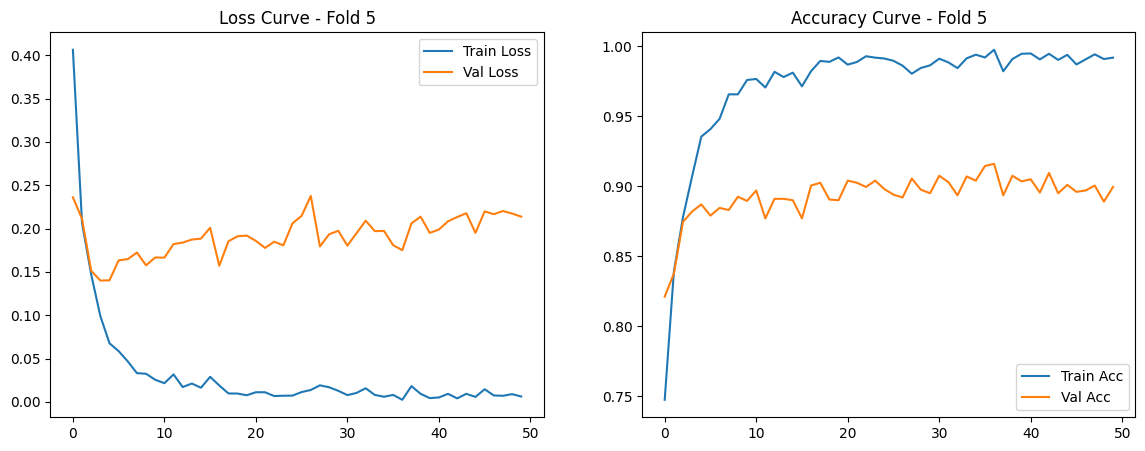

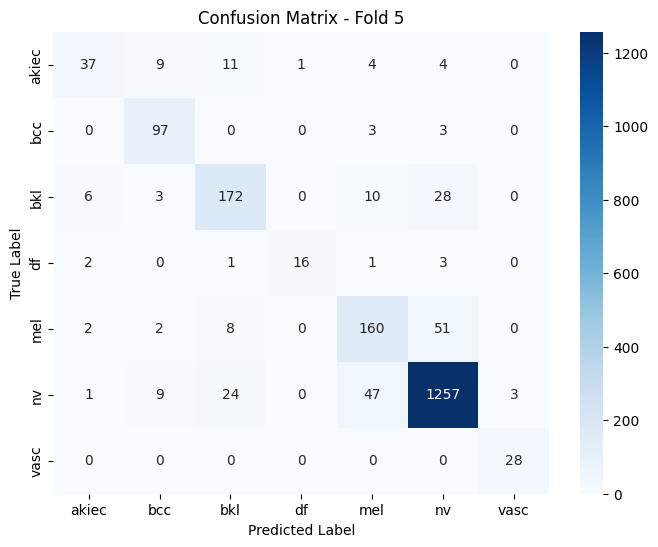

Semua log dan grafik untuk Fold 5 berhasil disimpan di folder: results_exp0

ALHAMDULILLAH, EKSPERIMEN basdeline SELESAI TOTAL!
Semua grafik, metric, dan file .pth telah diamankan.


In [9]:
# CELL 7: MASTER EXECUTION LOOP (RUN EXPERIMENT 1)
import torch.optim as optim

# Hyperparameters
BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4

print(f"Mulai Eksperimen 0: ConvNeXt Baseline + Focal Loss")
print(f"Menyimpan di folder: {SAVE_DIR}\n" + "="*50)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n---> Memulai Fold {fold} <---")
    
    # Bagi dataframe berdasarkan index fold
    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]
    
    # Buat Dataset dan DataLoader
    train_dataset = HAM10000Dataset(train_df, transform=train_transform)
    val_dataset = HAM10000Dataset(val_df, transform=val_transform)
    
    # Gunakan num_workers=4 atau 8 jika CPU Xeon Anda mendukung untuk mempercepat I/O
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Inisialisasi Ulang Model dan Optimizer untuk setiap Fold
    model = ConvNeXt_Baseline(num_classes=7).to(device)
    criterion = FocalLoss(gamma=2) # Mengatasi Imbalance
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # Mulai Training
    history, t_time, max_mem = train_model(
        fold=fold, 
        model=model, 
        train_loader=train_loader, 
        val_loader=val_loader, 
        criterion=criterion, 
        optimizer=optimizer, 
        num_epochs=NUM_EPOCHS
    )
    
    # Mulai Evaluasi & Plotting
    evaluate_and_plot(
        fold=fold, 
        model=model, 
        val_loader=val_loader, 
        history=history, 
        training_time=t_time, 
        max_memory=max_mem, 
        class_names=class_names
    )
    
print("\n" + "="*50)
print("ALHAMDULILLAH, EKSPERIMEN basdeline SELESAI TOTAL!")
print("Semua grafik, metric, dan file .pth telah diamankan.")

In [1]:
# CELL 8: SUMMARY CALCULATOR (MEAN & STD) - FIXED VERSION
import os
import pandas as pd
import glob

# Pastikan path folder benar sesuai hasil running tadi
results_path = "results_exp0"
csv_files = glob.glob(os.path.join(results_path, "exp0_fold*_classification_report.csv"))

if len(csv_files) < 5:
    print(f"Peringatan: Baru ditemukan {len(csv_files)} file CSV. Pastikan 5 fold sudah selesai running semua.")
else:
    all_reports = []
    
    for file in csv_files:
        # Perbaikan: index_col=0 digunakan agar kolom pertama (nama kelas) jadi index
        df_fold = pd.read_csv(file, index_col=0) 
        all_reports.append(df_fold)
    
    # Gabungkan semua fold
    full_concat = pd.concat(all_reports)
    
    # Hitung rata-rata (Mean) dan Standar Deviasi (Std)
    mean_report = full_concat.groupby(full_concat.index).mean()
    std_report = full_concat.groupby(full_concat.index).std()

    # Mengambil metrik utama (Accuracy dan Macro F1)
    # Note: Di report sklearn, accuracy biasanya ada di baris 'accuracy' kolom 'precision'
    mean_accuracy = mean_report.loc['accuracy', 'precision']
    mean_macro_f1 = mean_report.loc['macro avg', 'f1-score']
    
    std_accuracy = std_report.loc['accuracy', 'precision']
    std_macro_f1 = std_report.loc['macro avg', 'f1-score']
    
    print("="*50)
    print("   HASIL AKHIR EKSPERIMEN 0 (STATISTIK 5-FOLD)")
    print("="*50)
    print(f"Mean Accuracy : {mean_accuracy:.4f} ± {std_accuracy:.4f}")
    print(f"Mean Macro F1 : {mean_macro_f1:.4f} ± {std_macro_f1:.4f}")
    print("-" * 50)
    
    # Tampilkan tabel lengkap rata-rata per kelas agar bisa langsung di-copy ke Paper
    print("\nLaporan Lengkap (Mean Performance per Class):")
    target_rows = class_names + ['macro avg', 'weighted avg']
    summary_table = mean_report.loc[target_rows, ['precision', 'recall', 'f1-score']]
    
    # Menampilkan tabel
    from IPython.display import display
    display(summary_table)
    
    # Simpan hasil akhir ke CSV untuk arsip
    summary_table.to_csv(os.path.join(results_path, "EXP0_FINAL_SUMMARY_STATISTICS.csv"))
    print(f"\n[INFO] Laporan final telah disimpan di: {results_path}/EXP0_FINAL_SUMMARY_STATISTICS.csv")

   HASIL AKHIR EKSPERIMEN 0 (STATISTIK 5-FOLD)
Mean Accuracy : 0.8970 ± 0.0112
Mean Macro F1 : 0.8342 ± 0.0168
--------------------------------------------------

Laporan Lengkap (Mean Performance per Class):


NameError: name 'class_names' is not defined